In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
customer_df = pd.read_csv("customer_features.csv")
orders_df = pd.read_csv("master_orders.csv")

In [2]:
#Customer Pareto Analysis (Revenue)
# Sort customers by spending
pareto = (
    customer_df.groupby("customer_unique_id")["total_spent"]
      .sum()
      .reset_index()
      .sort_values("total_spent", ascending=False)
)
# Cumulative calculations
pareto["Cumulative Sales"] = pareto["total_spent"].cumsum()
pareto["Cumulative %"] = (
    pareto["Cumulative Sales"] /
    pareto["total_spent"].sum()
) * 100
pareto["Customer %"] = (
    range(1, len(pareto)+1)
)
pareto["Customer %"] = (
    pareto["Customer %"] /
    len(pareto)
) * 100

In [3]:
pareto

,customer_unique_id,total_spent,Cumulative Sales,Cumulative %,Customer %
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08,1.366408e+04,0.086165,0.001041
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02,2.321710e+04,0.146406,0.002081
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63,3.078873e+04,0.194152,0.003122
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,3.806361e+04,0.240027,0.004163
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31,4.499292e+04,0.283722,0.005203
...,...,...,...,...,...
74468,c63a8c4fb13043a3fbe33bd17c69d17d,4.34,1.585807e+07,99.999974,99.995837
14015,2524dcec233c3766f2c2b22f69fd65f4,4.07,1.585807e+07,100.000000,99.996878
49312,830d5b7aaa3b6f1e9ad63703bec97d23,0.00,1.585807e+07,100.000000,99.997919
56519,968fac81e2c44fb6c1e3ac2a45e6a102,0.00,1.585807e+07,100.000000,99.998959


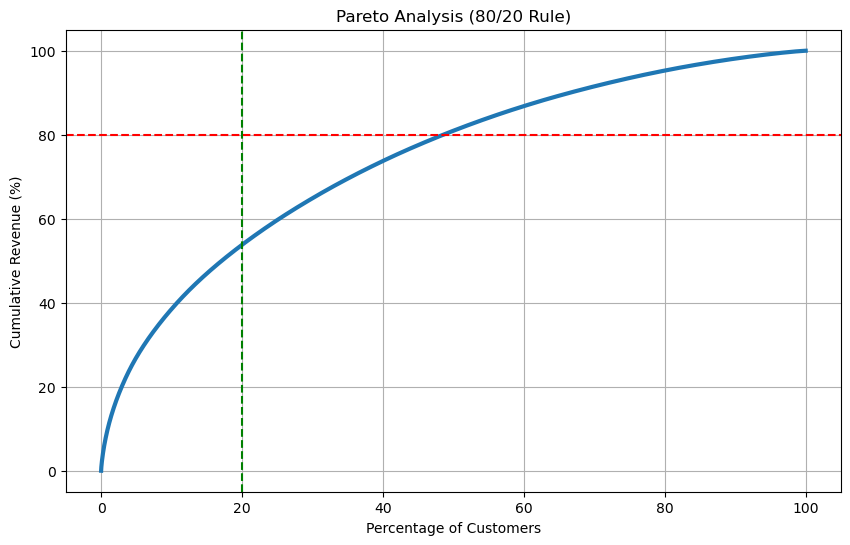

In [4]:
plt.figure(figsize=(10,6))
plt.plot(
    pareto["Customer %"].to_numpy(),
    pareto["Cumulative %"].to_numpy(),
    linewidth=3
)
plt.axhline(80, color="red", linestyle="--")
plt.axvline(20, color="green", linestyle="--")
plt.xlabel("Percentage of Customers")
plt.ylabel("Cumulative Revenue (%)")
plt.title("Pareto Analysis (80/20 Rule)")
plt.grid(True)
plt.show()

In [5]:
#Customers creating 80% of revenue
top_customers = pareto[pareto["Cumulative %"] <= 80]
print("Customers contributing to first 80% revenue:")
print(len(top_customers))
print("Percentage of customers:")
print(round(
    len(top_customers)/len(pareto)*100,
    2
),"%")

Customers contributing to first 80% revenue:
46635
Percentage of customers:
48.53 %


In [6]:
#2. Product Category Pareto Analysis
category = (
    orders_df.groupby("product_category_name_english")["payment_value"]
    .sum()
    .reset_index()
)
category = category.sort_values(
    "payment_value",
    ascending=False
)
category["Cumulative Sales"] = category["payment_value"].cumsum()
category["Cumulative %"] = (
    category["Cumulative Sales"] /
    category["payment_value"].sum()
)*100
category["Category %"] = (
    range(1,len(category)+1)
)
category["Category %"] = (
    category["Category %"] /
    len(category)
)*100

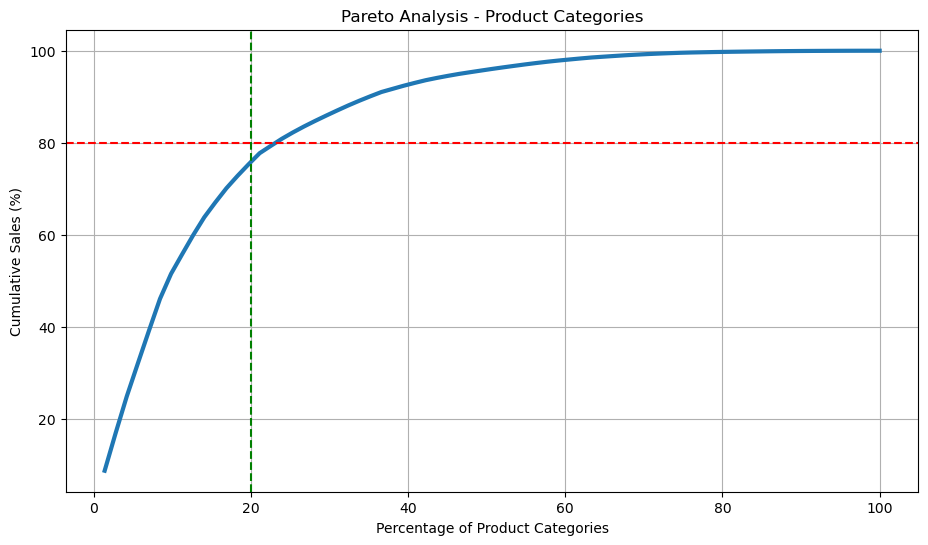

In [7]:
plt.figure(figsize=(11,6))
plt.plot(
    category["Category %"].to_numpy(),
    category["Cumulative %"].to_numpy(),
    linewidth=3
)
plt.axhline(80,color="red",linestyle="--")
plt.axvline(20,color="green",linestyle="--")
plt.xlabel("Percentage of Product Categories")
plt.ylabel("Cumulative Sales (%)")
plt.title("Pareto Analysis - Product Categories")
plt.grid(True)
plt.show()

In [8]:
# Top Categories contributing to 80%
top_categories = category[
    category["Cumulative %"]<=80
]
top_categories

,product_category_name_english,payment_value,Cumulative Sales,Cumulative %,Category %
7,bed_bath_table,1743998.80,1743998.80,8.652245,1.408451
43,health_beauty,1662963.59,3406962.39,16.902461,2.816901
15,computers_accessories,1599481.06,5006443.45,24.837731,4.225352
39,furniture_decor,1443963.61,6450407.06,32.001456,5.633803
70,watches_gifts,1430553.48,7880960.54,39.098650,7.042254
65,sports_leisure,1400223.07,9281183.61,46.045371,8.450704
49,housewares,1097900.09,10379083.70,51.492221,9.859155
5,auto,855095.68,11234179.38,55.734482,11.267606
42,garden_tools,840721.59,12074900.97,59.905430,12.676056
20,cool_stuff,781933.97,12856834.94,63.784724,14.084507


In [9]:
#3. State Pareto Analysis
state = (
    orders_df.groupby("customer_state")["payment_value"]
    .sum()
    .reset_index()
)
state = state.sort_values(
    "payment_value",
    ascending=False
)
state["Cumulative Sales"] = state["payment_value"].cumsum()

state["Cumulative %"] = (
    state["Cumulative Sales"] /
    state["payment_value"].sum()
)*100
state["State %"] = (
    range(1,len(state)+1)
)
state["State %"] = (
    state["State %"] /
    len(state)
)*100

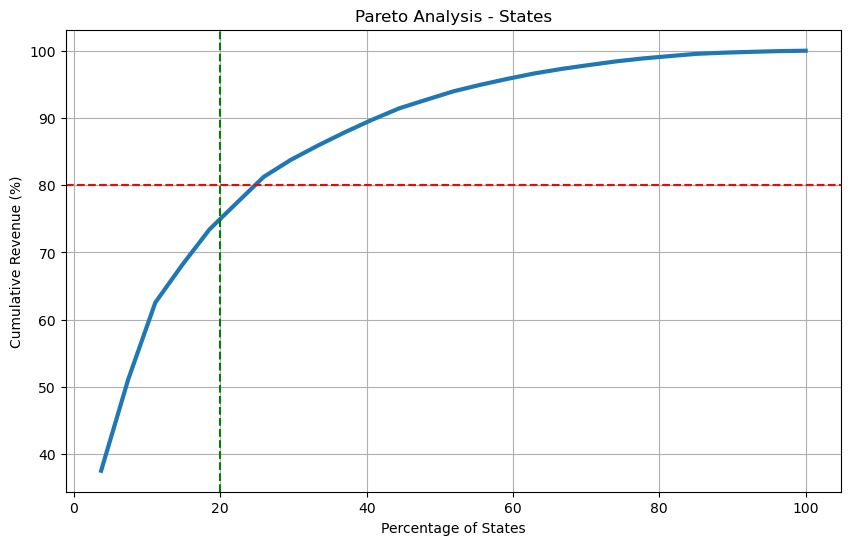

In [10]:
plt.figure(figsize=(10,6))
plt.plot(
    state["State %"].to_numpy(),
    state["Cumulative %"].to_numpy(),
    linewidth=3
)
plt.axhline(80,color="red",linestyle="--")
plt.axvline(20,color="green",linestyle="--")
plt.xlabel("Percentage of States")
plt.ylabel("Cumulative Revenue (%)")
plt.title("Pareto Analysis - States")
plt.grid(True)
plt.show()

In [11]:
top_states = state[
    state["Cumulative %"]<=80
]
top_states

,customer_state,payment_value,Cumulative Sales,Cumulative %,State %
25,SP,7726078.35,7726078.35,37.542296,3.703704
18,RJ,2795615.67,10521694.02,51.126656,7.407407
10,MG,2351221.09,12872915.11,62.551629,11.111111
22,RS,1160175.66,14033090.77,68.189115,14.814815
17,PR,1079795.49,15112886.26,73.436020,18.518519
4,BA,805070.98,15917957.24,77.347994,22.222222


1) Approximately 45% of customers contribute to 80% of the total revenue, indicating that a relatively small customer segment drives most sales.

2) A limited number of product categories (16) account for around 80% of total sales, suggesting these categories are the primary revenue drivers.

3) Revenue is concentrated in a small number of states (6), highlighting key regional markets where marketing and inventory efforts can be prioritized.

4) These results support targeted strategies such as loyalty programs for high-value customers, optimized stock planning for top-performing categories, and region-specific marketing campaigns.